In [2]:
!pip install seaborn


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
 
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten, Dense, Dropout,
    LSTM, GRU, BatchNormalization, GlobalAveragePooling1D,
    Input, Bidirectional, Add, Activation
)
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
import numpy as np
import joblib
import tensorflow as tf
import os

EXPORT_DIR = r"C:\Users\PC\Desktop\MIT_2\comparison_data"

# ── Load data ─────────────────────────────────────────────
X_train = np.load(os.path.join(EXPORT_DIR, "X_train.npy"))
X_test  = np.load(os.path.join(EXPORT_DIR, "X_test.npy"))
y_train = np.load(os.path.join(EXPORT_DIR, "y_train.npy"))
y_test  = np.load(os.path.join(EXPORT_DIR, "y_test.npy"))
hr_test = np.load(os.path.join(EXPORT_DIR, "hr_test.npy"))

print("✅ Data loaded")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

# ── Load your existing trained models ─────────────────────
cnn_arrhythmia_model = tf.keras.models.load_model(os.path.join(EXPORT_DIR, "cnn_arrhythmia_model.keras"))
lstm_vitals_model    = tf.keras.models.load_model(os.path.join(EXPORT_DIR, "lstm_vitals_model.keras"))
rf_model             = joblib.load(os.path.join(EXPORT_DIR, "rf_model.pkl"))

print("✅ Models loaded")

# ── Flatten for sklearn models ────────────────────────────
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

✅ Data loaded
X_train: (96823, 300, 1)
X_test:  (24206, 300, 1)
y_train: (96823,)
y_test:  (24206,)
✅ Models loaded


In [7]:

# ── Flatten for sklearn models ────────────────────────────
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)
 
NUM_CLASSES = 3
EPOCHS      = 15
BATCH       = 64
INPUT_SHAPE = (300, 1)
 
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
 
results   = {}   # stores metrics per model
histories = {}   # stores keras training histories
 

In [11]:

# ══════════════════════════════════════════════════════════
#  CATEGORY 1 — CLASSICAL ML (5 models)
# ══════════════════════════════════════════════════════════
 
def eval_sklearn(name, clf):
    print(f"\n▶ Training {name}...")
    t0 = time.time()
    clf.fit(X_train_flat, y_train)
    train_time = time.time() - t0
 
    t0 = time.time()
    y_pred = clf.predict(X_test_flat)
    infer_time = (time.time() - t0) / len(X_test_flat) * 1000  # ms per sample
 
    y_prob = clf.predict_proba(X_test_flat) if hasattr(clf, 'predict_proba') else None
 
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)
 
    if y_prob is not None:
        y_bin = label_binarize(y_test, classes=[0,1,2])
        auc   = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='weighted')
    else:
        auc = None
 
    results[name] = {
        'accuracy': acc, 'f1': f1, 'precision': prec,
        'recall': rec, 'auc': auc,
        'cm': cm, 'y_pred': y_pred, 'y_prob': y_prob,
        'train_time': train_time, 'infer_ms': infer_time,
        'category': 'Classical ML', 'history': None
    }
    print(f"   ✅ Acc={acc:.4f}  F1={f1:.4f}  Time={train_time:.1f}s")
    return clf
 
rf_comp  = eval_sklearn("Random Forest",        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
et_comp  = eval_sklearn("Extra Trees",           ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1))
gb_comp  = eval_sklearn("Gradient Boosting",     GradientBoostingClassifier(n_estimators=100, random_state=42))
svm_comp = eval_sklearn("SVM (RBF)",             SVC(kernel='rbf', C=1, probability=True, random_state=42))
knn_comp = eval_sklearn("KNN (k=5)",             KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
 


▶ Training Random Forest...
   ✅ Acc=0.9896  F1=0.9895  Time=6.7s

▶ Training Extra Trees...
   ✅ Acc=0.9911  F1=0.9910  Time=2.7s

▶ Training Gradient Boosting...
   ✅ Acc=0.9748  F1=0.9745  Time=943.5s

▶ Training SVM (RBF)...
   ✅ Acc=0.9831  F1=0.9830  Time=1205.5s

▶ Training KNN (k=5)...
   ✅ Acc=0.9901  F1=0.9901  Time=0.0s


  CATEGORY 2 — CNN VARIANTS (5 models)

In [12]:

def eval_keras(name, model, category):
    print(f"\n▶ Training {name}...")
    t0 = time.time()
    h = model.fit(
        X_train, y_train,
        epochs=EPOCHS, batch_size=BATCH,
        validation_data=(X_test, y_test),
        callbacks=[early_stop], verbose=0
    )
    train_time = time.time() - t0
    histories[name] = h
 
    t0 = time.time()
    y_prob = model.predict(X_test, verbose=0)
    infer_time = (time.time() - t0) / len(X_test) * 1000
 
    y_pred = np.argmax(y_prob, axis=1)
    y_bin  = label_binarize(y_test, classes=[0,1,2])
 
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)
    auc  = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='weighted')
 
    results[name] = {
        'accuracy': acc, 'f1': f1, 'precision': prec,
        'recall': rec, 'auc': auc,
        'cm': cm, 'y_pred': y_pred, 'y_prob': y_prob,
        'train_time': train_time, 'infer_ms': infer_time,
        'category': category, 'history': h
    }
    print(f"   ✅ Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  Time={train_time:.1f}s")
    return model
 

In [13]:

# --- CNN 1: Simple CNN ---
def build_simple_cnn():
    m = Sequential([
        Conv1D(32, 5, activation='relu', input_shape=INPUT_SHAPE),
        MaxPooling1D(2),
        Conv1D(64, 5, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

In [14]:

# --- CNN 2: Deep CNN with BN ---
def build_deep_cnn():
    m = Sequential([
        Conv1D(32, 5, activation='relu', input_shape=INPUT_SHAPE),
        BatchNormalization(), MaxPooling1D(2),
        Conv1D(64, 5, activation='relu'),
        BatchNormalization(), MaxPooling1D(2),
        Conv1D(128, 3, activation='relu'),
        BatchNormalization(), MaxPooling1D(2),
        Flatten(),
        Dense(128, activation='relu'), Dropout(0.5),
        Dense(64, activation='relu'),  Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m
 

In [15]:

# --- CNN 3: Dilated CNN ---
def build_dilated_cnn():
    inp = Input(shape=INPUT_SHAPE)
    x = Conv1D(32, 3, padding='causal', dilation_rate=1, activation='relu')(inp)
    x = Conv1D(32, 3, padding='causal', dilation_rate=2, activation='relu')(x)
    x = Conv1D(64, 3, padding='causal', dilation_rate=4, activation='relu')(x)
    x = Conv1D(64, 3, padding='causal', dilation_rate=8, activation='relu')(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)
    out = Dense(NUM_CLASSES, activation='softmax')(x)
    m = Model(inp, out)
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m
 

In [16]:

# --- CNN 4: Residual CNN ---
def build_residual_cnn():
    inp = Input(shape=INPUT_SHAPE)
    x = Conv1D(64, 5, padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)
 
    # Residual block 1
    res = Conv1D(64, 5, padding='same')(x)
    res = BatchNormalization()(res)
    res = Activation('relu')(res)
    res = Conv1D(64, 5, padding='same')(res)
    res = BatchNormalization()(res)
    x   = Add()([x, res])
    x   = Activation('relu')(x)
    x   = MaxPooling1D(2)(x)
 
    # Residual block 2
    x2  = Conv1D(128, 5, padding='same')(x)
    x2  = BatchNormalization()(x2)
    x2  = Activation('relu')(x2)
    x2  = Conv1D(128, 5, padding='same')(x2)
    x2  = BatchNormalization()(x2)
    xp  = Conv1D(128, 1, padding='same')(x)   # projection shortcut
    x   = Add()([xp, x2])
    x   = Activation('relu')(x)
    x   = MaxPooling1D(2)(x)
 
    x   = GlobalAveragePooling1D()(x)
    x   = Dense(64, activation='relu')(x)
    x   = Dropout(0.4)(x)
    out = Dense(NUM_CLASSES, activation='softmax')(x)
    m   = Model(inp, out)
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

In [17]:

# --- CNN 5: Multi-scale CNN ---
def build_multiscale_cnn():
    inp  = Input(shape=INPUT_SHAPE)
    b1   = Conv1D(32, 3, padding='same', activation='relu')(inp)
    b2   = Conv1D(32, 7, padding='same', activation='relu')(inp)
    b3   = Conv1D(32, 15, padding='same', activation='relu')(inp)
    from tensorflow.keras.layers import Concatenate
    x    = Concatenate()([b1, b2, b3])
    x    = MaxPooling1D(2)(x)
    x    = Conv1D(128, 5, activation='relu')(x)
    x    = BatchNormalization()(x)
    x    = GlobalAveragePooling1D()(x)
    x    = Dense(64, activation='relu')(x)
    x    = Dropout(0.4)(x)
    out  = Dense(NUM_CLASSES, activation='softmax')(x)
    m    = Model(inp, out)
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m
 
eval_keras("Simple CNN",      build_simple_cnn(),      "CNN Variants")
eval_keras("Deep CNN + BN",   build_deep_cnn(),        "CNN Variants")
eval_keras("Dilated CNN",     build_dilated_cnn(),     "CNN Variants")
eval_keras("Residual CNN",    build_residual_cnn(),    "CNN Variants")
eval_keras("Multi-scale CNN", build_multiscale_cnn(),  "CNN Variants")


▶ Training Simple CNN...
   ✅ Acc=0.9931  F1=0.9931  AUC=0.9995  Time=37.3s

▶ Training Deep CNN + BN...
   ✅ Acc=0.9950  F1=0.9950  AUC=0.9996  Time=72.4s

▶ Training Dilated CNN...
   ✅ Acc=0.9816  F1=0.9814  AUC=0.9968  Time=81.2s

▶ Training Residual CNN...
   ✅ Acc=0.9915  F1=0.9915  AUC=0.9988  Time=262.9s

▶ Training Multi-scale CNN...
   ✅ Acc=0.9781  F1=0.9779  AUC=0.9957  Time=62.9s


CATEGORY 3 — RNN VARIANTS (5 models)

In [18]:

# --- RNN 1: Simple LSTM ---
def build_simple_lstm():
    m = Sequential([
        LSTM(64, input_shape=INPUT_SHAPE),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m
 

In [19]:

# --- RNN 2: Stacked LSTM ---
def build_stacked_lstm():
    m = Sequential([
        LSTM(128, return_sequences=True, input_shape=INPUT_SHAPE),
        Dropout(0.3),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32),
        Dense(32, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m
 

In [20]:

# --- RNN 3: Bidirectional LSTM ---
def build_bilstm():
    m = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=INPUT_SHAPE),
        Dropout(0.3),
        Bidirectional(LSTM(32)),
        Dense(32, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m
 

In [21]:

# --- RNN 4: GRU ---
def build_gru():
    m = Sequential([
        GRU(64, return_sequences=True, input_shape=INPUT_SHAPE),
        Dropout(0.3),
        GRU(32),
        Dense(32, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

In [22]:

# --- RNN 5: CNN + LSTM Hybrid ---
def build_cnn_lstm():
    m = Sequential([
        Conv1D(64, 5, activation='relu', input_shape=INPUT_SHAPE),
        MaxPooling1D(2),
        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),
        LSTM(64, return_sequences=False),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m
 
eval_keras("Simple LSTM",     build_simple_lstm(),  "RNN Variants")
eval_keras("Stacked LSTM",    build_stacked_lstm(), "RNN Variants")
eval_keras("BiLSTM",          build_bilstm(),       "RNN Variants")
eval_keras("GRU",             build_gru(),          "RNN Variants")
eval_keras("CNN + LSTM",      build_cnn_lstm(),     "RNN Variants")
 


▶ Training Simple LSTM...
   ✅ Acc=0.9810  F1=0.9808  AUC=0.9925  Time=503.5s

▶ Training Stacked LSTM...
   ✅ Acc=0.9844  F1=0.9844  AUC=0.9970  Time=1303.0s

▶ Training BiLSTM...
   ✅ Acc=0.9880  F1=0.9880  AUC=0.9978  Time=941.4s

▶ Training GRU...
   ✅ Acc=0.9903  F1=0.9902  AUC=0.9991  Time=526.3s

▶ Training CNN + LSTM...
   ✅ Acc=0.9939  F1=0.9939  AUC=0.9994  Time=122.9s


 BUILD SUMMARY DATAFRAME

In [23]:

df = pd.DataFrame([
    {
        'Model':      name,
        'Category':   v['category'],
        'Accuracy':   round(v['accuracy'],  4),
        'F1':         round(v['f1'],        4),
        'Precision':  round(v['precision'], 4),
        'Recall':     round(v['recall'],    4),
        'AUC':        round(v['auc'], 4) if v['auc'] else None,
        'Train(s)':   round(v['train_time'], 1),
        'Infer(ms)':  round(v['infer_ms'],   3),
    }
    for name, v in results.items()
]).sort_values('F1', ascending=False).reset_index(drop=True)
 
print("\n" + "="*90)
print(" MODEL COMPARISON SUMMARY")
print("="*90)
print(df.to_string(index=False))
print("="*90)
print(f"\n🏆 Best model: {df.iloc[0]['Model']}  (F1 = {df.iloc[0]['F1']})")
 


 MODEL COMPARISON SUMMARY
            Model     Category  Accuracy     F1  Precision  Recall    AUC  Train(s)  Infer(ms)
    Deep CNN + BN CNN Variants    0.9950 0.9950     0.9950  0.9950 0.9996      72.4      0.037
       CNN + LSTM RNN Variants    0.9939 0.9939     0.9939  0.9939 0.9994     122.9      0.088
       Simple CNN CNN Variants    0.9931 0.9931     0.9931  0.9931 0.9995      37.3      0.034
     Residual CNN CNN Variants    0.9915 0.9915     0.9915  0.9915 0.9988     262.9      0.117
      Extra Trees Classical ML    0.9911 0.9910     0.9911  0.9911 0.9996       2.7      0.003
              GRU RNN Variants    0.9903 0.9902     0.9903  0.9903 0.9991     526.3      0.301
        KNN (k=5) Classical ML    0.9901 0.9901     0.9901  0.9901 0.9965       0.0      0.257
    Random Forest Classical ML    0.9896 0.9895     0.9896  0.9896 0.9993       6.7      0.003
           BiLSTM RNN Variants    0.9880 0.9880     0.9880  0.9880 0.9978     941.4      0.612
     Stacked LSTM RNN V

PLOTTING


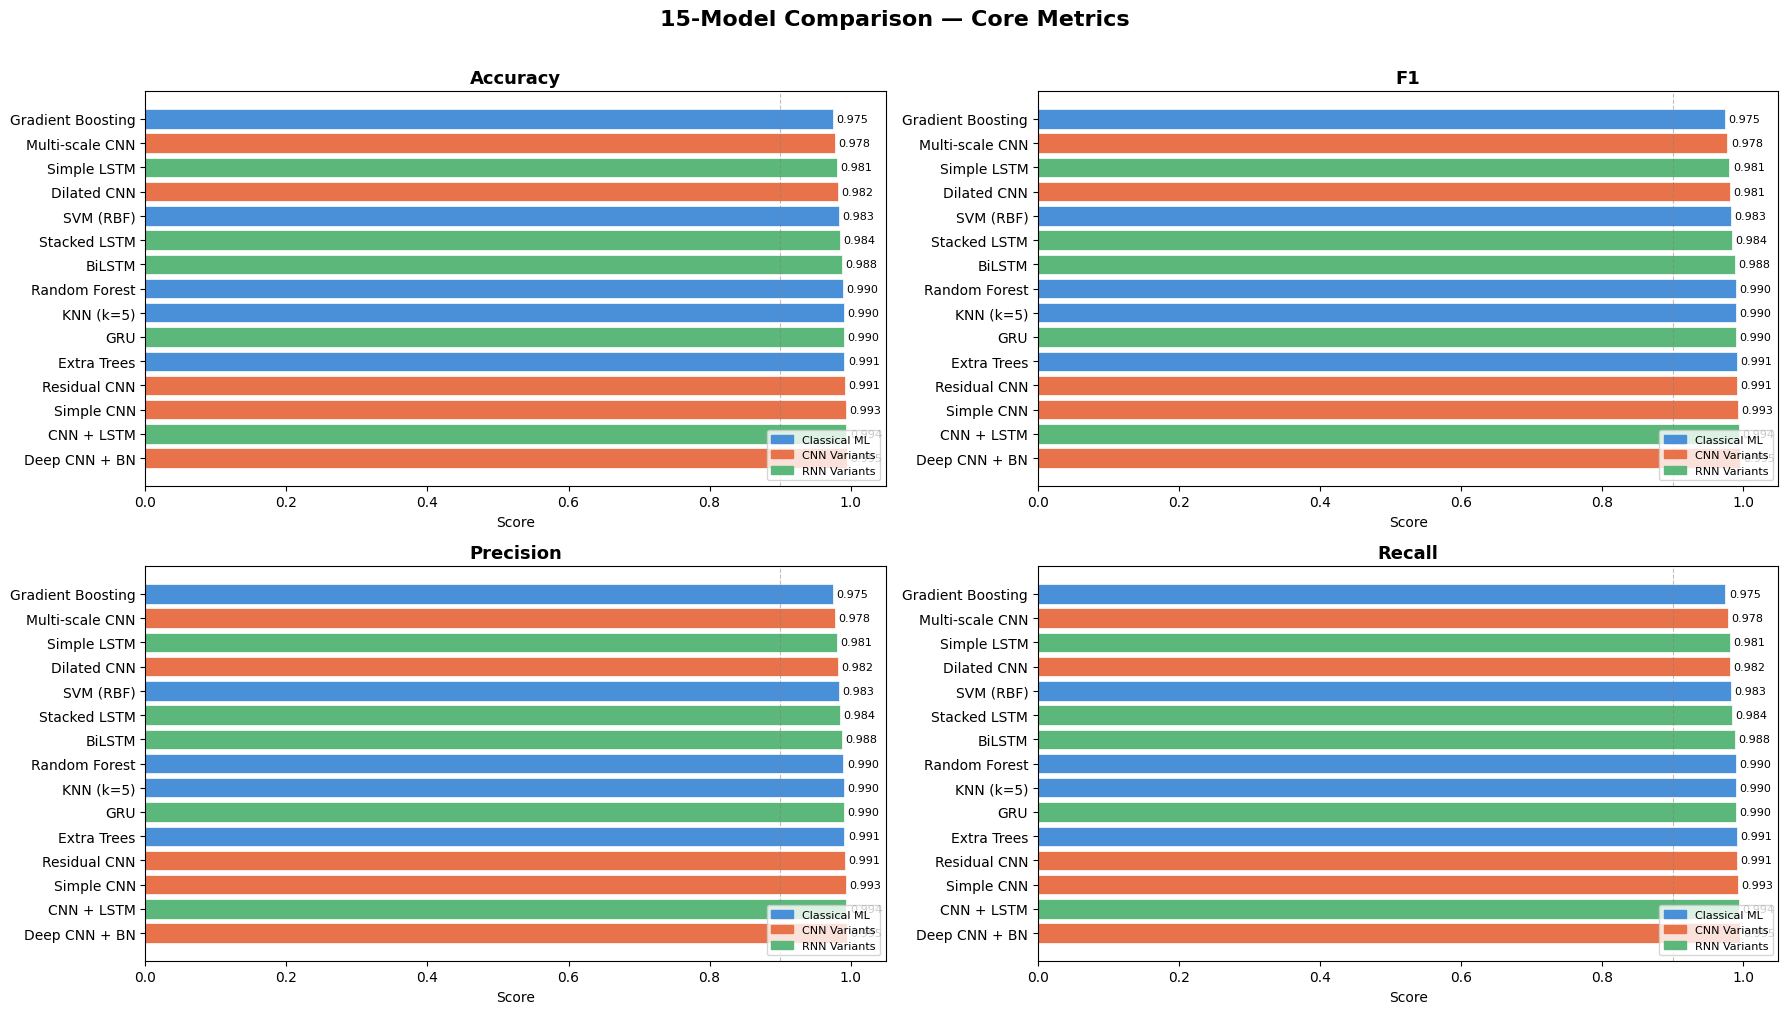

✅ Saved: comparison_metrics.png


In [24]:

COLORS = {
    'Classical ML': '#4A90D9',
    'CNN Variants': '#E8734A',
    'RNN Variants': '#5CB87A'
}
 
def cat_color(cat):
    return COLORS.get(cat, '#888')
 
model_names = df['Model'].tolist()
cat_colors  = [cat_color(df.loc[df['Model']==n, 'Category'].values[0]) for n in model_names]
 
# ── 1. Bar charts: Accuracy, F1, Precision, Recall ───────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("15-Model Comparison — Core Metrics", fontsize=16, fontweight='bold', y=1.01)
 
metrics = ['Accuracy', 'F1', 'Precision', 'Recall']
for ax, metric in zip(axes.flat, metrics):
    vals = [results[n][metric.lower()] for n in model_names]
    bars = ax.barh(model_names, vals, color=cat_colors, edgecolor='white', linewidth=0.5)
    ax.set_xlim(0, 1.05)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel("Score")
    ax.axvline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    # Legend
    from matplotlib.patches import Patch
    handles = [Patch(color=c, label=l) for l, c in COLORS.items()]
    ax.legend(handles=handles, fontsize=8, loc='lower right')
 
plt.tight_layout()
plt.savefig("comparison_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: comparison_metrics.png")
 

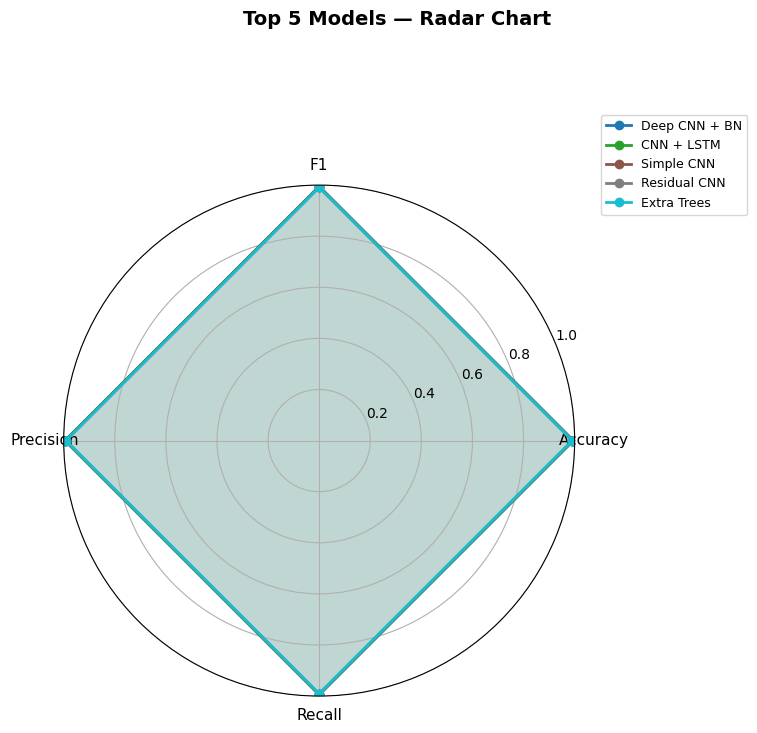

✅ Saved: radar_top5.png


In [25]:

# ── 2. Radar chart ────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
 
top5 = df.head(5)['Model'].tolist()
radar_metrics = ['Accuracy', 'F1', 'Precision', 'Recall']
N = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
 
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle("Top 5 Models — Radar Chart", fontsize=14, fontweight='bold')
 
radar_colors = plt.cm.tab10(np.linspace(0, 1, 5))
for i, name in enumerate(top5):
    vals = [results[name][m.lower()] for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=name, color=radar_colors[i])
    ax.fill(angles, vals, alpha=0.08, color=radar_colors[i])
 
ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig("radar_top5.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: radar_top5.png")
 

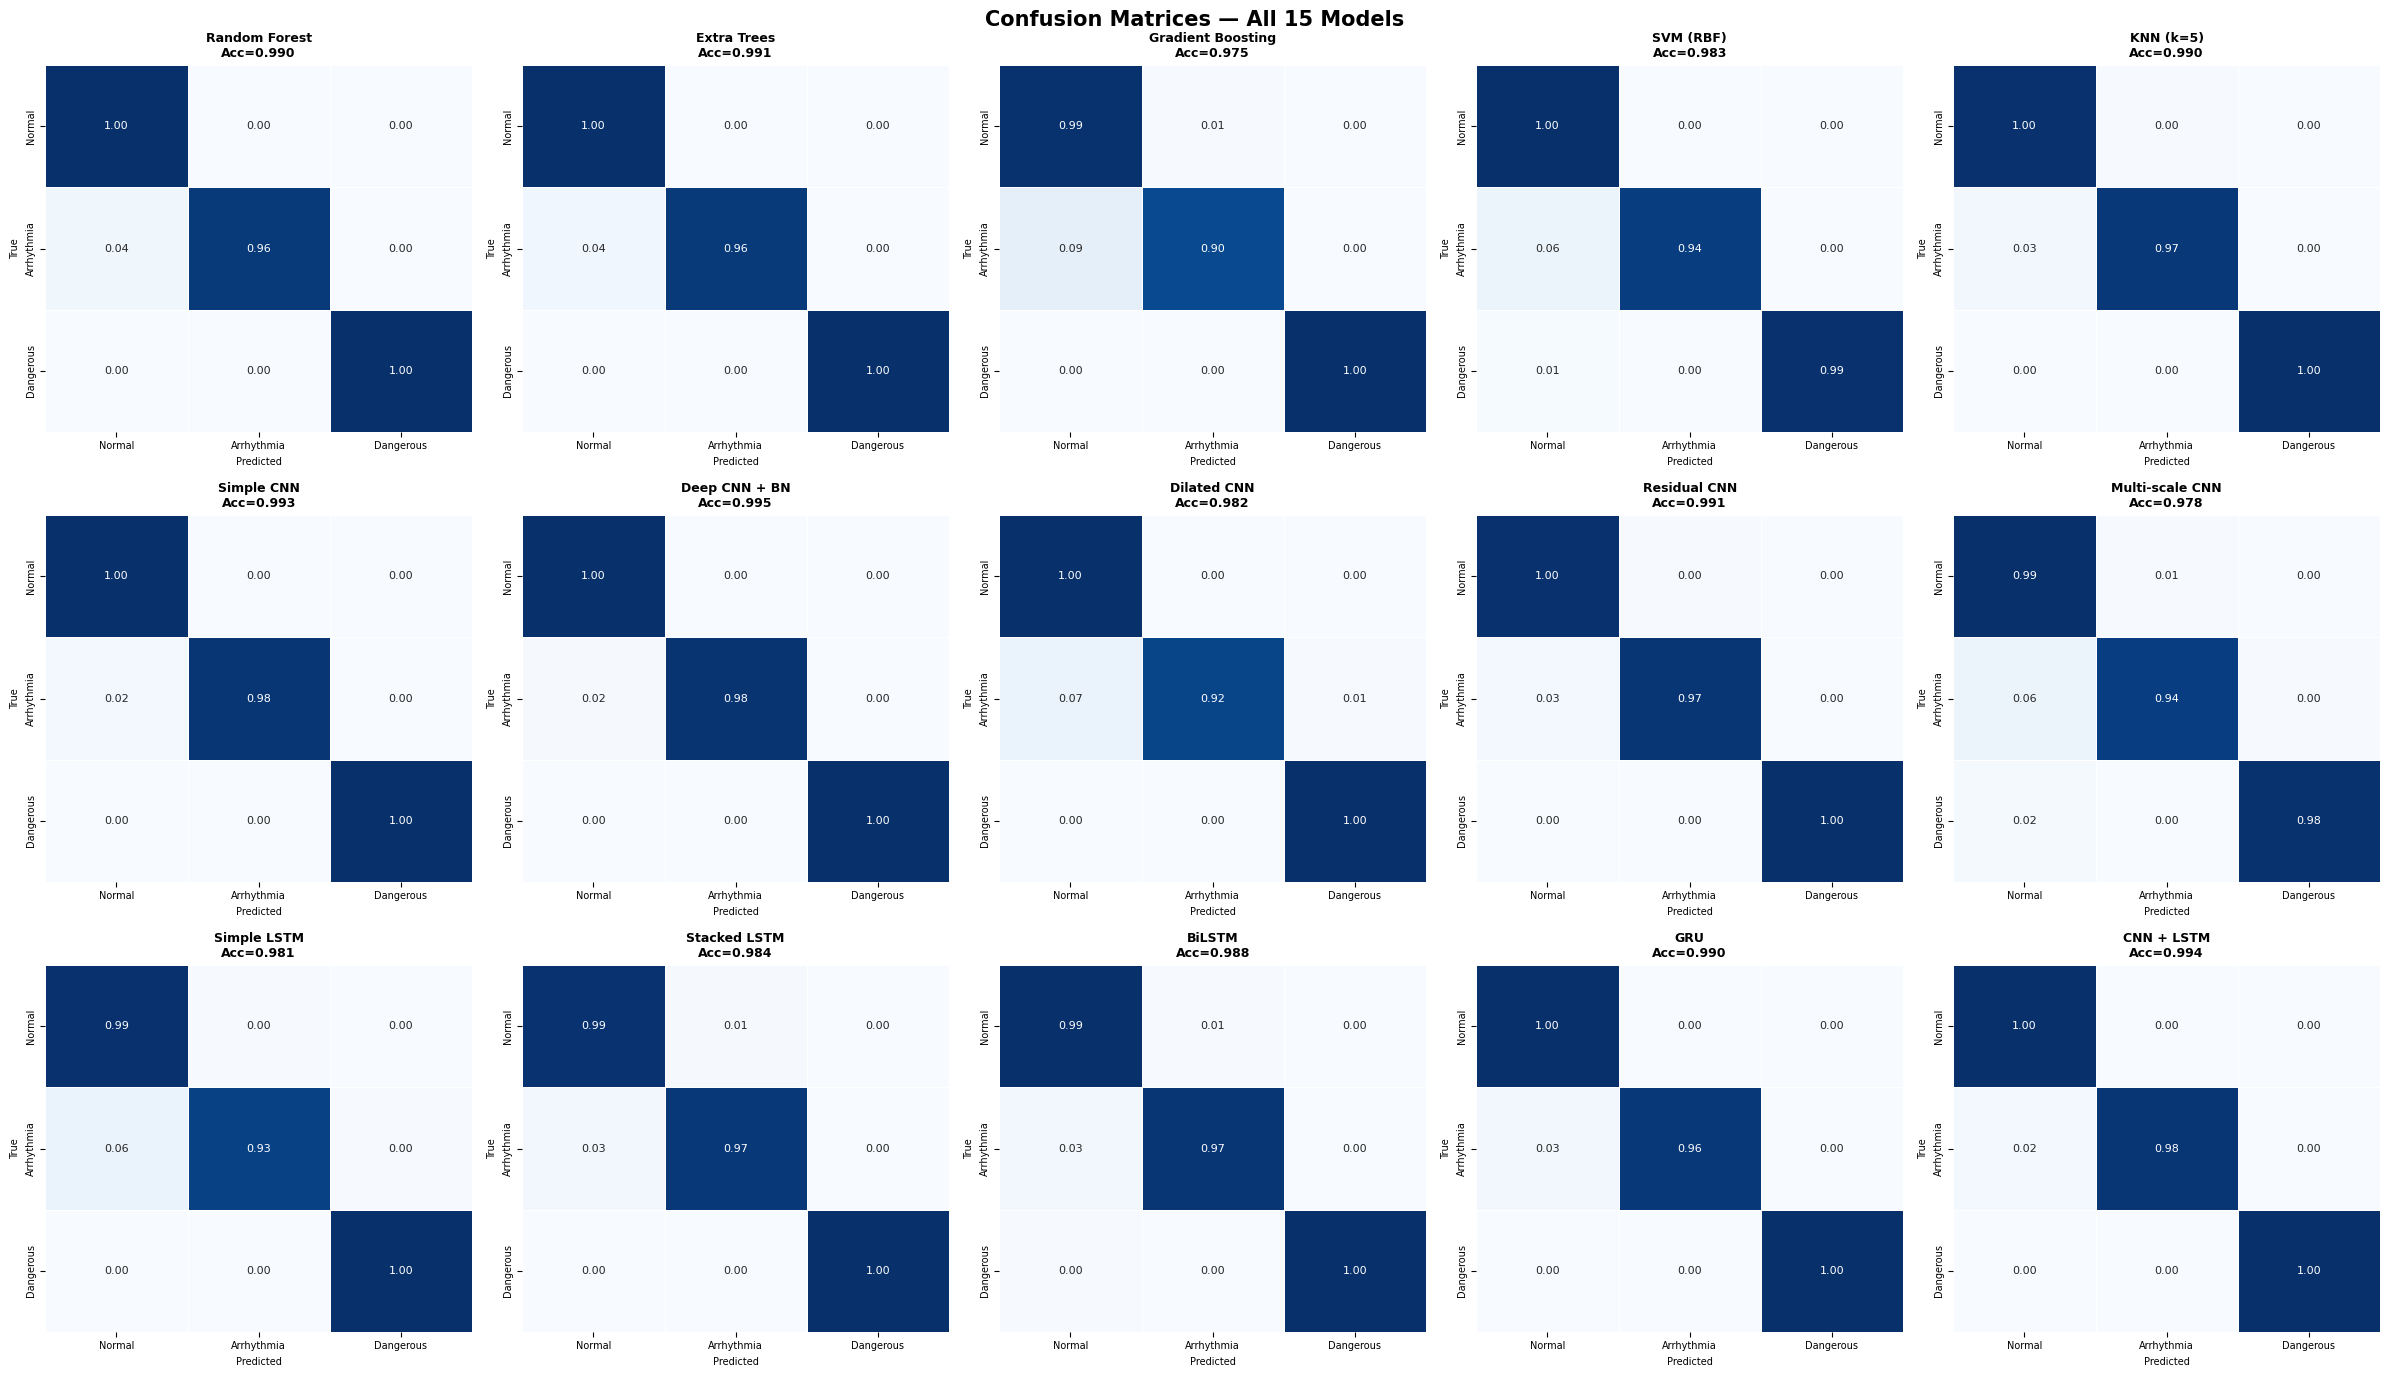

✅ Saved: confusion_matrices_all.png


In [26]:

# ── 3. Confusion matrices (all 15) ───────────────────────
fig, axes = plt.subplots(3, 5, figsize=(24, 14))
fig.suptitle("Confusion Matrices — All 15 Models", fontsize=15, fontweight='bold')
class_names = ['Normal', 'Arrhythmia', 'Dangerous']
 
for ax, (name, v) in zip(axes.flat, results.items()):
    cm_norm = v['cm'].astype('float') / v['cm'].sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
                cmap='Blues', xticklabels=class_names,
                yticklabels=class_names, linewidths=0.5,
                cbar=False, annot_kws={"size": 8})
    ax.set_title(f"{name}\nAcc={v['accuracy']:.3f}", fontsize=9, fontweight='bold')
    ax.set_xlabel("Predicted", fontsize=7)
    ax.set_ylabel("True", fontsize=7)
    ax.tick_params(labelsize=7)
 
plt.tight_layout()
plt.savefig("confusion_matrices_all.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrices_all.png")
 

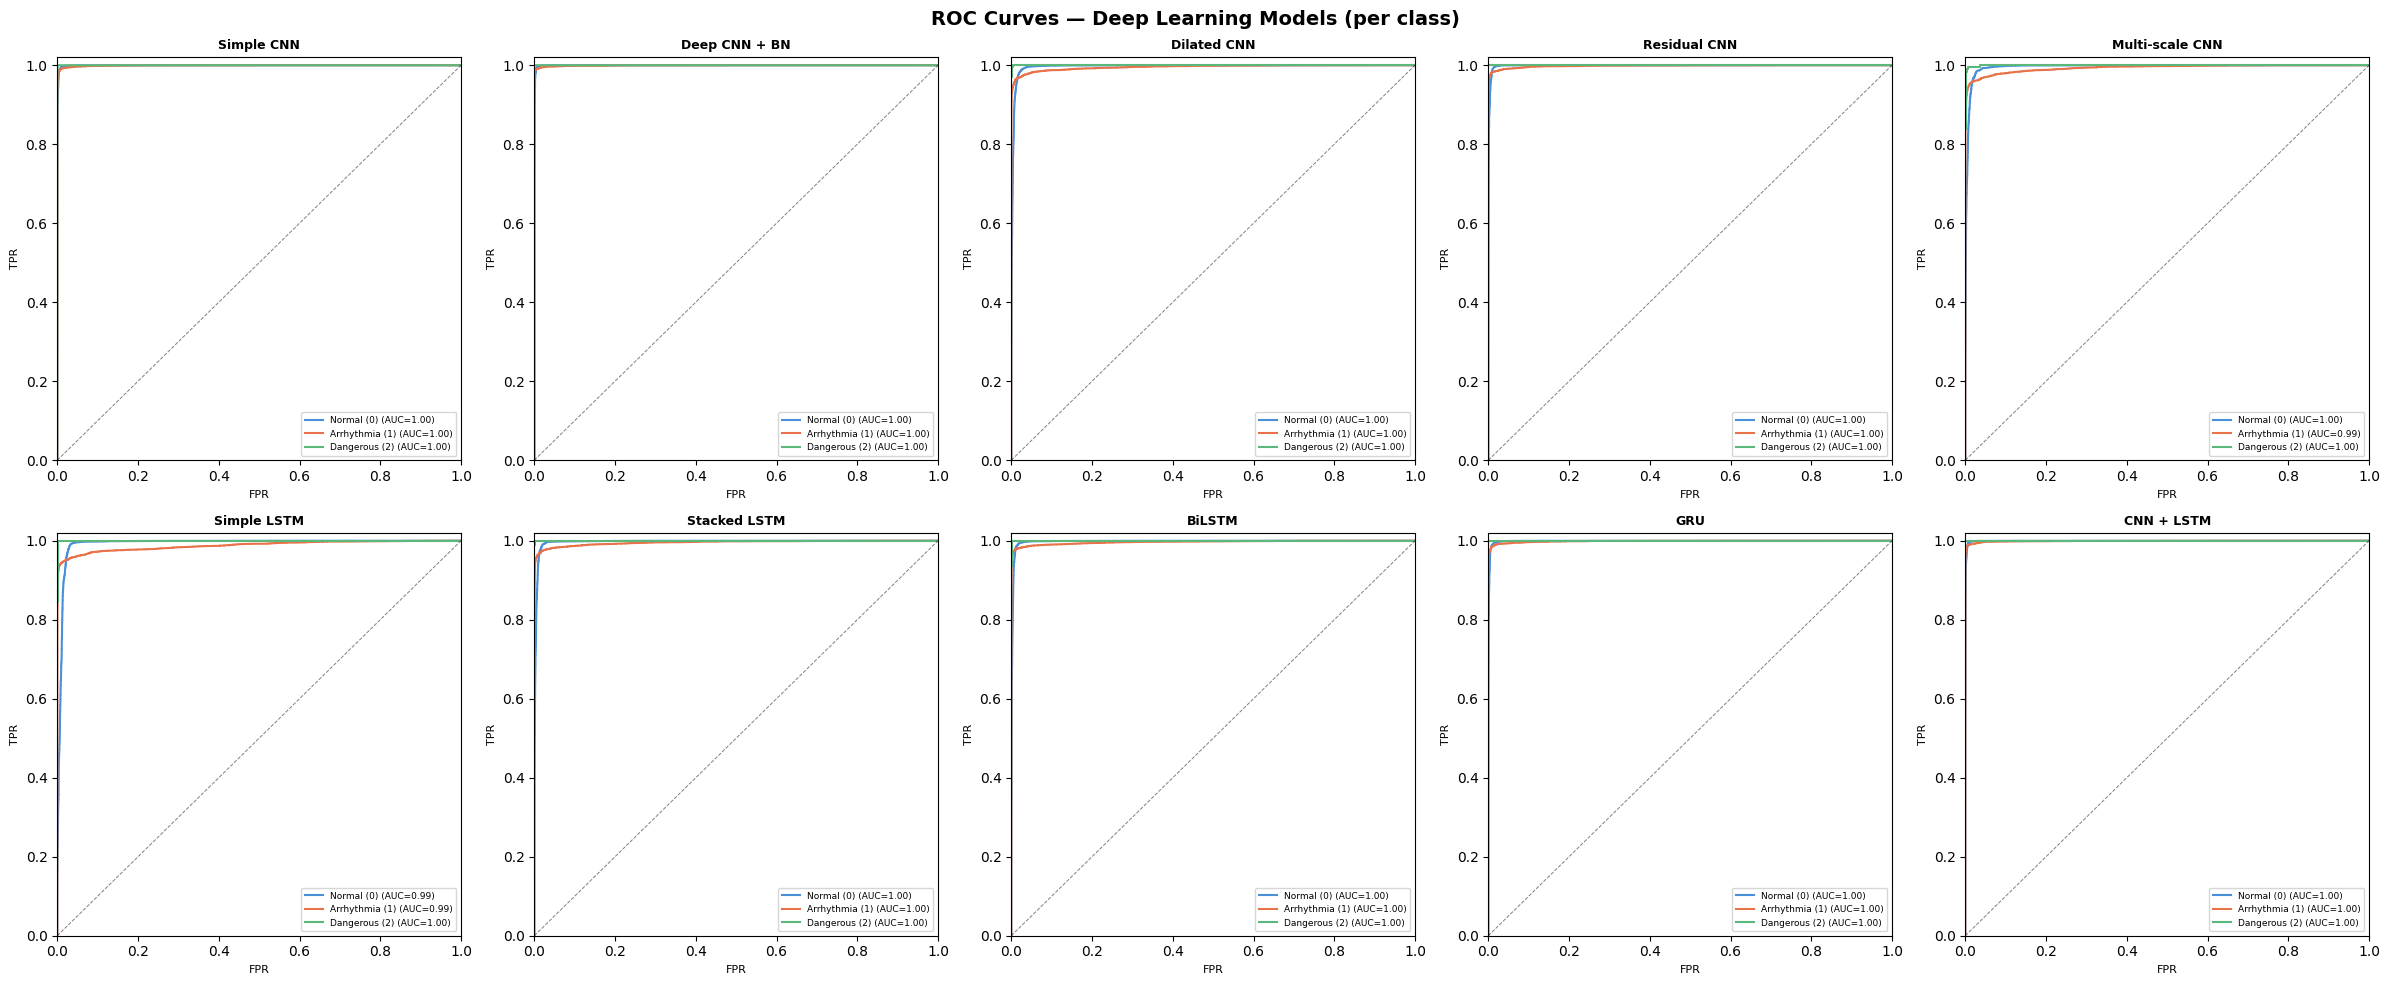

✅ Saved: roc_curves_dl.png


In [27]:

# ── 4. ROC curves (deep learning models only) ────────────
dl_models = {n: v for n, v in results.items()
             if v['category'] in ['CNN Variants', 'RNN Variants'] and v['y_prob'] is not None}
 
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
fig.suptitle("ROC Curves — Deep Learning Models (per class)", fontsize=14, fontweight='bold')
class_labels = ['Normal (0)', 'Arrhythmia (1)', 'Dangerous (2)']
roc_colors   = ['#4A90D9', '#E8734A', '#5CB87A']
y_bin_test   = label_binarize(y_test, classes=[0, 1, 2])
 
for ax, (name, v) in zip(axes.flat, dl_models.items()):
    for cls in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin_test[:, cls], v['y_prob'][:, cls])
        auc_cls = roc_auc_score(y_bin_test[:, cls], v['y_prob'][:, cls])
        ax.plot(fpr, tpr, color=roc_colors[cls],
                label=f"{class_labels[cls]} (AUC={auc_cls:.2f})", linewidth=1.5)
    ax.plot([0,1],[0,1],'k--', linewidth=0.7, alpha=0.5)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel("FPR", fontsize=8)
    ax.set_ylabel("TPR", fontsize=8)
    ax.legend(fontsize=6.5)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
 
plt.tight_layout()
plt.savefig("roc_curves_dl.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: roc_curves_dl.png")
 

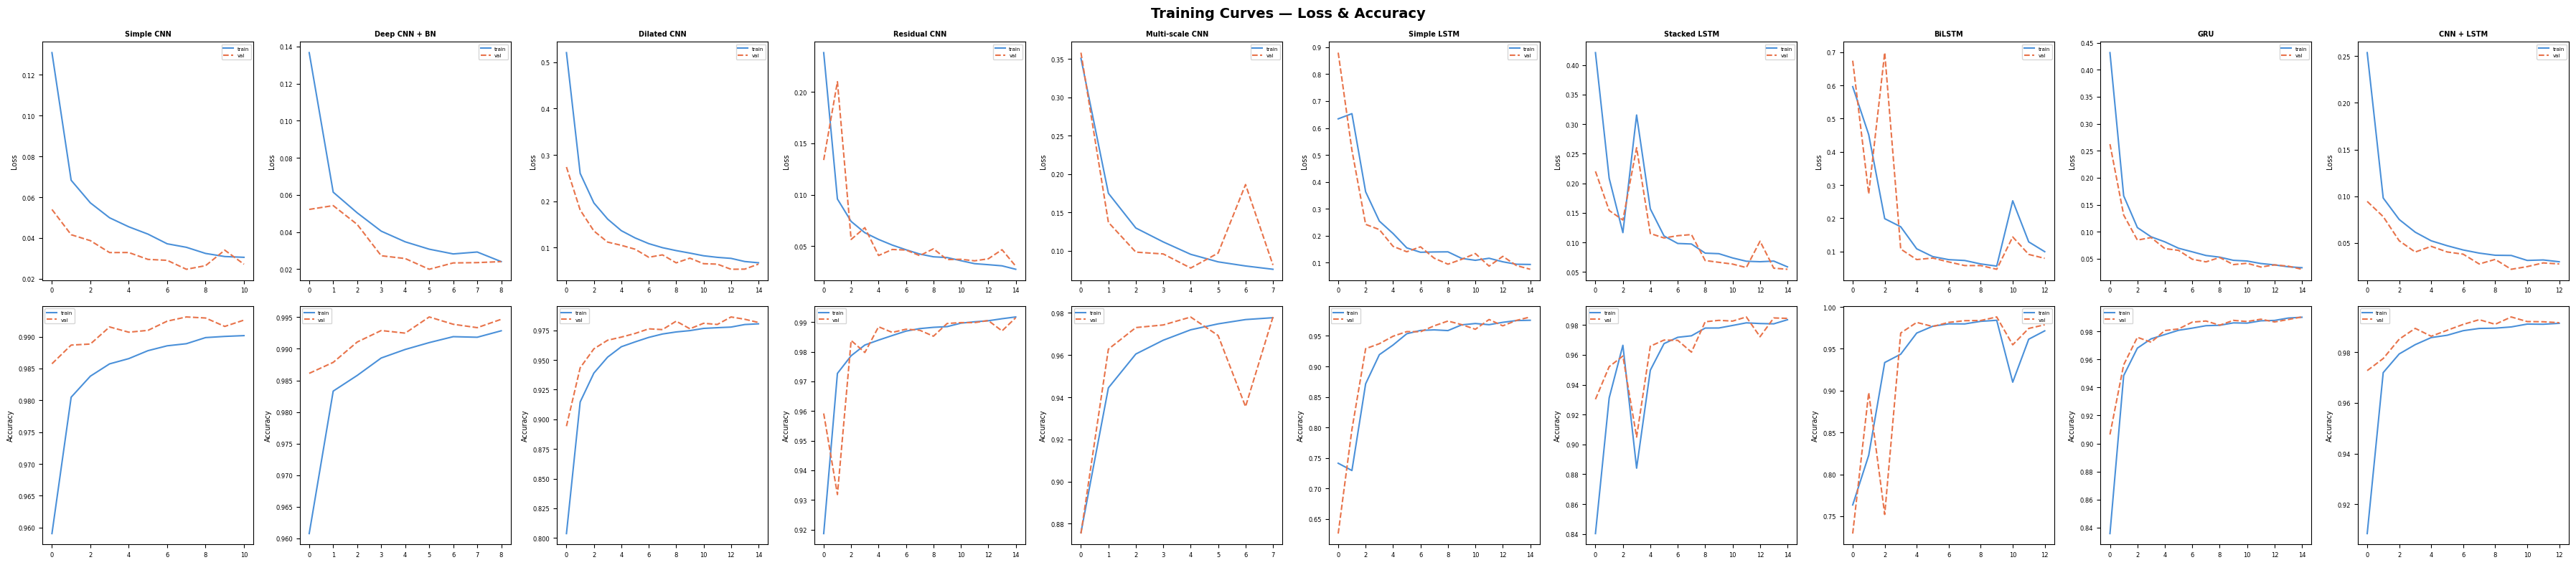

✅ Saved: training_curves.png


In [28]:

# ── 5. Training curves (loss + accuracy) ─────────────────
dl_with_history = {n: v for n, v in results.items() if v['history'] is not None}
 
fig, axes = plt.subplots(2, 10, figsize=(36, 8))
fig.suptitle("Training Curves — Loss & Accuracy", fontsize=14, fontweight='bold')
 
for col, (name, v) in enumerate(dl_with_history.items()):
    h = v['history'].history
    ax_loss = axes[0, col]
    ax_acc  = axes[1, col]
 
    ax_loss.plot(h['loss'],     label='train', color='#4A90D9')
    ax_loss.plot(h['val_loss'], label='val',   color='#E8734A', linestyle='--')
    ax_loss.set_title(name, fontsize=7, fontweight='bold')
    ax_loss.set_ylabel("Loss", fontsize=7)
    ax_loss.tick_params(labelsize=6)
    ax_loss.legend(fontsize=5)
 
    ax_acc.plot(h['accuracy'],     label='train', color='#4A90D9')
    ax_acc.plot(h['val_accuracy'], label='val',   color='#E8734A', linestyle='--')
    ax_acc.set_ylabel("Accuracy", fontsize=7)
    ax_acc.tick_params(labelsize=6)
    ax_acc.legend(fontsize=5)
 
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: training_curves.png")
 

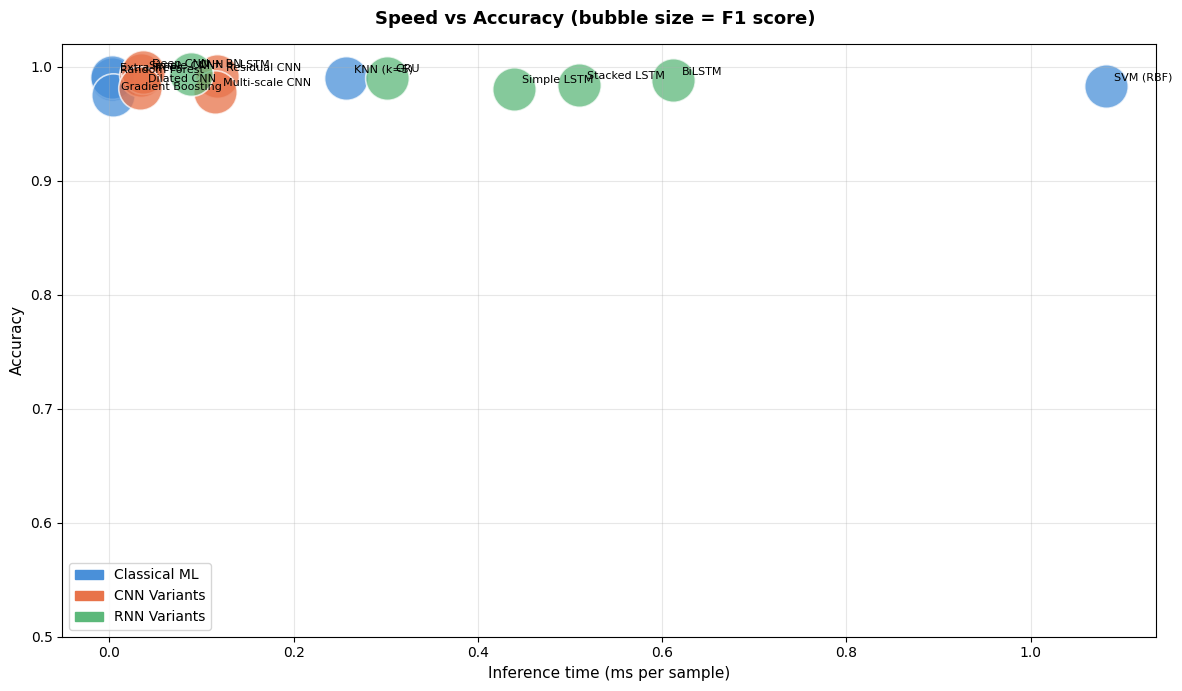

✅ Saved: speed_vs_accuracy.png


In [29]:

# ── 6. Speed vs Accuracy scatter ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Speed vs Accuracy (bubble size = F1 score)", fontsize=13, fontweight='bold')
 
for name, v in results.items():
    color = cat_color(v['category'])
    size  = v['f1'] * 1000
    ax.scatter(v['infer_ms'], v['accuracy'], s=size,
               color=color, alpha=0.75, edgecolors='white', linewidth=1.2)
    ax.annotate(name, (v['infer_ms'], v['accuracy']),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
 
handles = [Patch(color=c, label=l) for l, c in COLORS.items()]
ax.legend(handles=handles, fontsize=10)
ax.set_xlabel("Inference time (ms per sample)", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_ylim(0.5, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("speed_vs_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: speed_vs_accuracy.png")

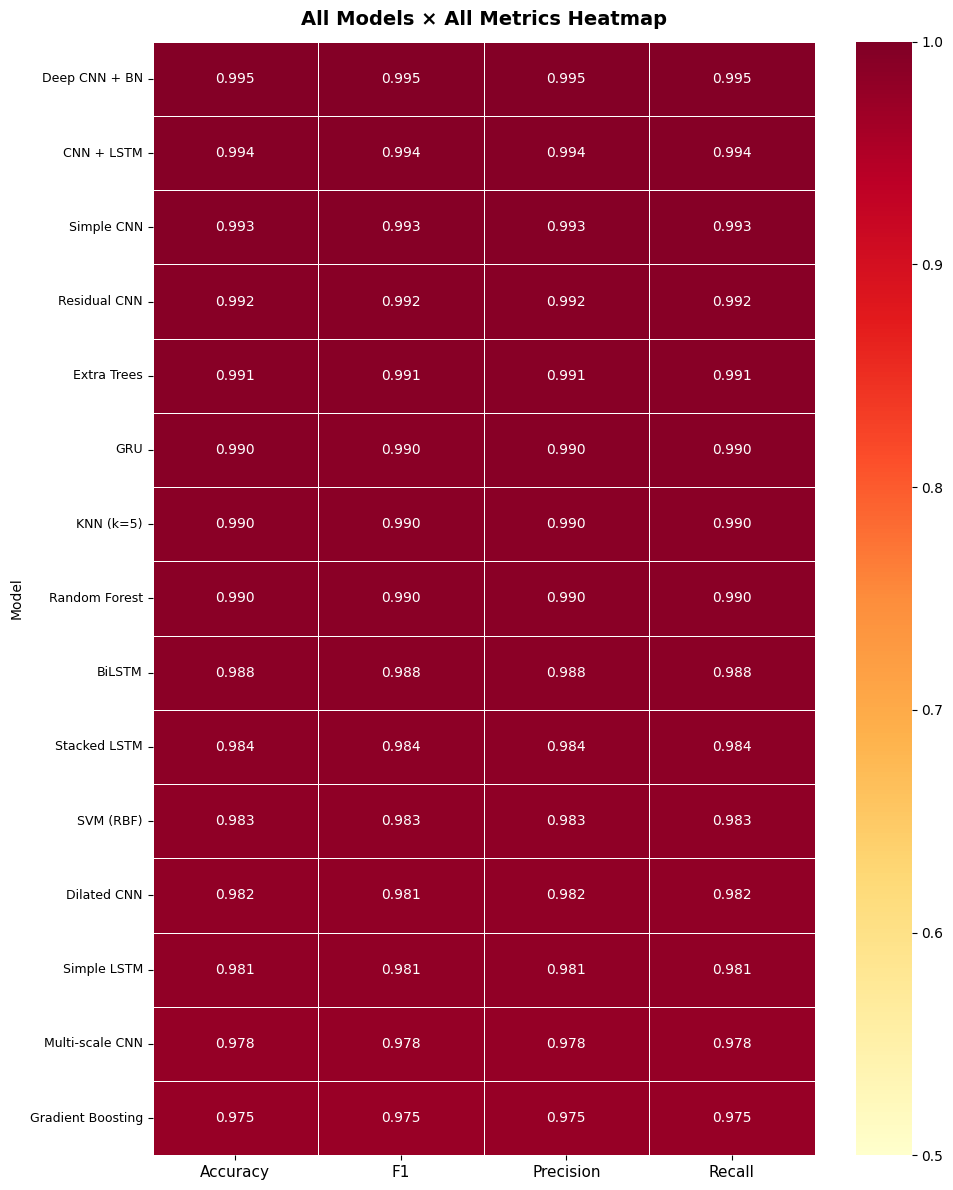

✅ Saved: metrics_heatmap.png


In [30]:

# ── 7. Heatmap — all metrics at once ─────────────────────
metric_cols = ['Accuracy', 'F1', 'Precision', 'Recall']
heat_df = df.set_index('Model')[metric_cols].astype(float)
 
fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0,
            annot_kws={"size": 10})
ax.set_title("All Models × All Metrics Heatmap", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("")
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.savefig("metrics_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: metrics_heatmap.png")

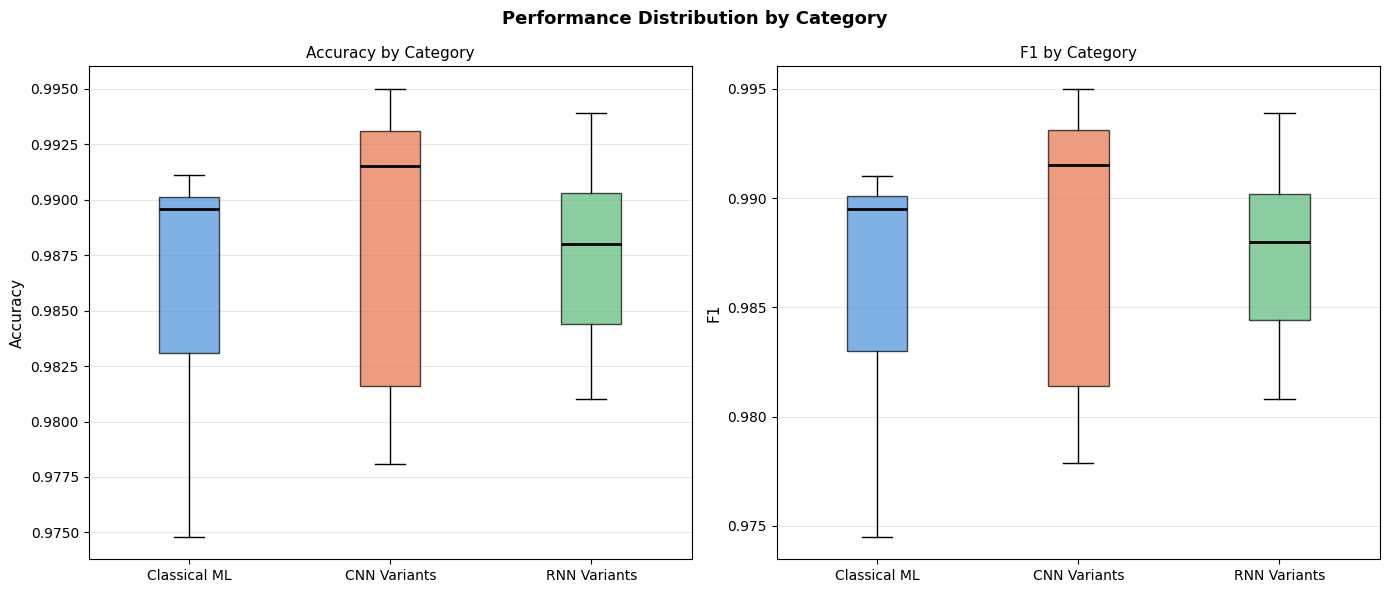

✅ Saved: category_boxplot.png


In [31]:

# ── 8. Category-level box plot ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Performance Distribution by Category", fontsize=13, fontweight='bold')
 
for ax, metric in zip(axes, ['Accuracy', 'F1']):
    data_by_cat = {cat: df[df['Category']==cat][metric].tolist() for cat in COLORS}
    bp = ax.boxplot(data_by_cat.values(), patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], COLORS.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(data_by_cat.keys(), fontsize=10)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f"{metric} by Category", fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
 
plt.tight_layout()
plt.savefig("category_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: category_boxplot.png")

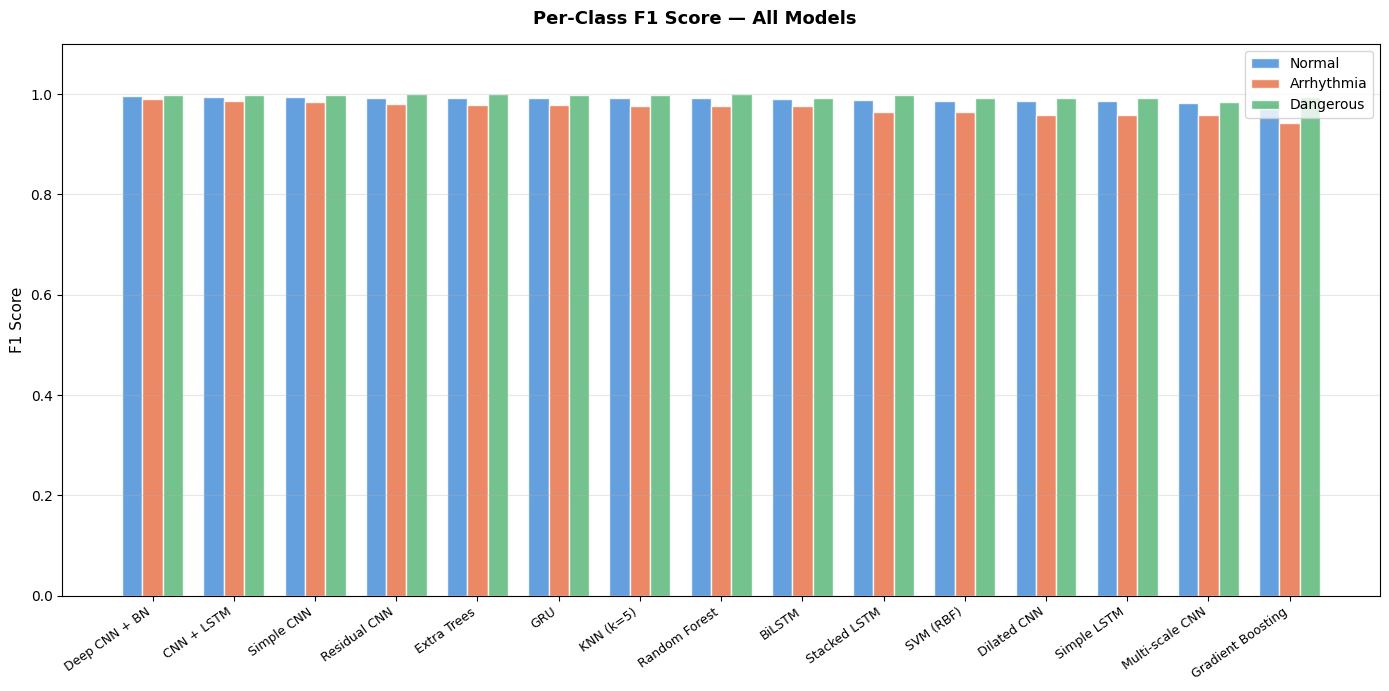

✅ Saved: perclass_f1.png


In [32]:

# ── 9. Per-class F1 breakdown ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Per-Class F1 Score — All Models", fontsize=13, fontweight='bold')
 
x       = np.arange(len(model_names))
width   = 0.25
cls_colors = ['#4A90D9', '#E8734A', '#5CB87A']
 
for cls in range(NUM_CLASSES):
    f1_per_class = []
    for name in model_names:
        report = classification_report(
            y_test, results[name]['y_pred'],
            output_dict=True, zero_division=0
        )
        f1_per_class.append(report.get(str(cls), {}).get('f1-score', 0))
    ax.bar(x + cls * width, f1_per_class, width, label=class_names[cls],
           color=cls_colors[cls], alpha=0.85, edgecolor='white')
 
ax.set_xticks(x + width)
ax.set_xticklabels(model_names, rotation=35, ha='right', fontsize=9)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("perclass_f1.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: perclass_f1.png")

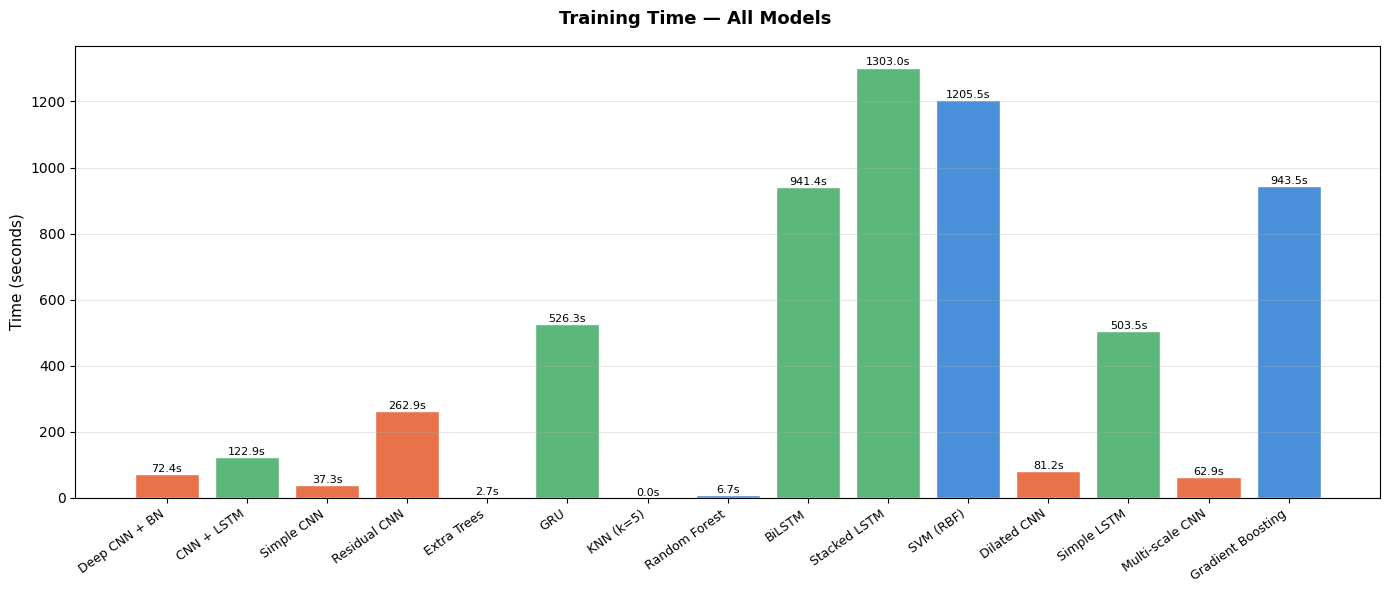

✅ Saved: training_time.png


In [33]:

 
# ── 10. Training time comparison ─────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Training Time — All Models", fontsize=13, fontweight='bold')
 
times  = [results[n]['train_time'] for n in model_names]
bars   = ax.bar(model_names, times, color=cat_colors, edgecolor='white')
ax.set_ylabel("Time (seconds)", fontsize=11)
ax.set_xticklabels(model_names, rotation=35, ha='right', fontsize=9)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{t:.1f}s', ha='center', va='bottom', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("training_time.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: training_time.png")

FINAL SUMMARY TABLE

In [34]:

print("\n" + "="*90)
print(" FINAL RANKED SUMMARY")
print("="*90)
print(df.to_string(index=False))
print("="*90)
 
best = df.iloc[0]
print(f"""
🏆 BEST OVERALL MODEL : {best['Model']}
   Category           : {best['Category']}
   Accuracy           : {best['Accuracy']}
   F1 Score           : {best['F1']}
   Precision          : {best['Precision']}
   Recall             : {best['Recall']}
   AUC                : {best['AUC']}
   Train time         : {best['Train(s)']}s
   Inference          : {best['Infer(ms)']}ms/sample
""")
 
print("\n📊 Charts saved:")
charts = [
    "comparison_metrics.png",
    "radar_top5.png",
    "confusion_matrices_all.png",
    "roc_curves_dl.png",
    "training_curves.png",
    "speed_vs_accuracy.png",
    "metrics_heatmap.png",
    "category_boxplot.png",
    "perclass_f1.png",
    "training_time.png"
]
for c in charts:
    print(f"   📈 {c}")


 FINAL RANKED SUMMARY
            Model     Category  Accuracy     F1  Precision  Recall    AUC  Train(s)  Infer(ms)
    Deep CNN + BN CNN Variants    0.9950 0.9950     0.9950  0.9950 0.9996      72.4      0.037
       CNN + LSTM RNN Variants    0.9939 0.9939     0.9939  0.9939 0.9994     122.9      0.088
       Simple CNN CNN Variants    0.9931 0.9931     0.9931  0.9931 0.9995      37.3      0.034
     Residual CNN CNN Variants    0.9915 0.9915     0.9915  0.9915 0.9988     262.9      0.117
      Extra Trees Classical ML    0.9911 0.9910     0.9911  0.9911 0.9996       2.7      0.003
              GRU RNN Variants    0.9903 0.9902     0.9903  0.9903 0.9991     526.3      0.301
        KNN (k=5) Classical ML    0.9901 0.9901     0.9901  0.9901 0.9965       0.0      0.257
    Random Forest Classical ML    0.9896 0.9895     0.9896  0.9896 0.9993       6.7      0.003
           BiLSTM RNN Variants    0.9880 0.9880     0.9880  0.9880 0.9978     941.4      0.612
     Stacked LSTM RNN Varia

In [35]:
# import os

# # ── SAVE EVERYTHING ──────────────────────────────────────────────────────────
# SAVE_DIR = r"C:\Users\PC\Desktop\MIT_2\saved_model"
# os.makedirs(SAVE_DIR, exist_ok=True)

# # 1. Save full model (architecture + weights + optimizer state)
# lstm_vitals_model.save(os.path.join(SAVE_DIR, "lstm_ecg_model.keras"))
# print("✅ Model saved →", os.path.join(SAVE_DIR, "lstm_ecg_model.keras"))

# # 2. Save training history (so you can plot later without retraining)
# import json
# history_path = os.path.join(SAVE_DIR, "training_history.json")
# with open(history_path, "w") as f:
#     json.dump(history.history, f)
# print("✅ History saved →", history_path)

# # 3. Save the scaler (needed to preprocess new data the same way)
# import joblib
# scaler_path = os.path.join(SAVE_DIR, "scaler.pkl")
# joblib.dump(scaler, scaler_path)
# print("✅ Scaler saved →", scaler_path)

# print("\n📁 All files in save dir:")
# for f in os.listdir(SAVE_DIR):
#     print("  ", f)


# CATEGORY 5 — TRANSFORMER MODELS FOR ECG

This section adds 4 advanced transformer-based architectures for ECG classification:

1. PatchTST
2. TimesNet-inspired Transformer
3. CNN + Transformer Hybrid
4. Temporal Fusion Transformer (Simplified)

These models are designed to work directly with your existing:
- `X_train`
- `X_test`
- `y_train`
- `y_test`
- `INPUT_SHAPE`
- `NUM_CLASSES`

pipeline already defined earlier in the notebook.


In [36]:

# ════════════════════════════════════════════════════════════════
# CATEGORY 5 — TRANSFORMER MODELS
# ════════════════════════════════════════════════════════════════

from tensorflow.keras.layers import (
    MultiHeadAttention,
    LayerNormalization,
    GlobalAveragePooling1D,
    Add,
    Dropout,
    Embedding,
    Dense,
    Conv1D,
    Input,
    LSTM
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [37]:

# ---------------------------------------------------------------
# Transformer Block
# ---------------------------------------------------------------

def transformer_block(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
    attn = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(x, x)

    x = Add()([x, attn])
    x = LayerNormalization(epsilon=1e-6)(x)

    ff = Dense(ff_dim, activation="relu")(x)
    ff = Dropout(dropout)(ff)
    ff = Dense(x.shape[-1])(ff)

    x = Add()([x, ff])
    x = LayerNormalization(epsilon=1e-6)(x)

    return x



In [38]:

# ---------------------------------------------------------------
# Shared evaluation function
# ---------------------------------------------------------------

def eval_transformer(name, model):
    print(f"\n▶ Training {name}...")

    model.compile(
        optimizer=Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    h = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=[early_stop],
        verbose=1
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    results[name] = {
        "Accuracy": float(acc),
        "Loss": float(loss)
    }

    histories[name] = h.history

    print(f"{name} Accuracy: {acc:.4f}")

    return model



In [39]:

# ════════════════════════════════════════════════════════════════
# 1. PatchTST
# ════════════════════════════════════════════════════════════════

def build_patchtst():

    inp = Input(shape=INPUT_SHAPE)

    x = Conv1D(64, kernel_size=16, strides=8, padding='same')(inp)

    x = transformer_block(x)

    x = transformer_block(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation='relu')(x)

    out = Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inp, out)


patchtst_model = build_patchtst()

eval_transformer("PatchTST", patchtst_model)




▶ Training PatchTST...
Epoch 1/15
1211/1211 [==============================] - 11s 8ms/step - loss: 0.3025 - accuracy: 0.8851 - val_loss: 0.1343 - val_accuracy: 0.9570
Epoch 2/15
1211/1211 [==============================] - 9s 7ms/step - loss: 0.1298 - accuracy: 0.9588 - val_loss: 0.0850 - val_accuracy: 0.9761
Epoch 3/15
1211/1211 [==============================] - 9s 7ms/step - loss: 0.1083 - accuracy: 0.9669 - val_loss: 0.0893 - val_accuracy: 0.9731
Epoch 4/15
1211/1211 [==============================] - 9s 7ms/step - loss: 0.0979 - accuracy: 0.9704 - val_loss: 0.0928 - val_accuracy: 0.9714
Epoch 5/15
1211/1211 [==============================] - 9s 7ms/step - loss: 0.0862 - accuracy: 0.9742 - val_loss: 0.0869 - val_accuracy: 0.9753
PatchTST Accuracy: 0.9745


In [40]:

# ════════════════════════════════════════════════════════════════
# 2. TimesNet Inspired Model
# ════════════════════════════════════════════════════════════════

def build_timesnet():

    inp = Input(shape=INPUT_SHAPE)

    x = Conv1D(64, 3, padding='same', activation='relu')(inp)
    x = Conv1D(64, 5, padding='same', activation='relu')(x)

    x = transformer_block(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation='relu')(x)

    out = Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inp, out)


timesnet_model = build_timesnet()

eval_transformer("TimesNet", timesnet_model)




▶ Training TimesNet...
Epoch 1/15
1211/1211 [==============================] - 33s 27ms/step - loss: 0.3963 - accuracy: 0.8409 - val_loss: 0.2738 - val_accuracy: 0.8808
Epoch 2/15
1211/1211 [==============================] - 32s 26ms/step - loss: 0.2242 - accuracy: 0.9162 - val_loss: 0.1764 - val_accuracy: 0.9384
Epoch 3/15
1211/1211 [==============================] - 34s 28ms/step - loss: 0.1734 - accuracy: 0.9380 - val_loss: 0.1829 - val_accuracy: 0.9302
Epoch 4/15
1211/1211 [==============================] - 39s 33ms/step - loss: 0.1428 - accuracy: 0.9522 - val_loss: 0.1309 - val_accuracy: 0.9572
Epoch 5/15
1211/1211 [==============================] - 37s 30ms/step - loss: 0.1255 - accuracy: 0.9593 - val_loss: 0.1569 - val_accuracy: 0.9506
Epoch 6/15
1211/1211 [==============================] - 37s 30ms/step - loss: 0.1098 - accuracy: 0.9658 - val_loss: 0.1177 - val_accuracy: 0.9635
Epoch 7/15
1211/1211 [==============================] - 37s 30ms/step - loss: 0.1001 - accuracy: 0.9

In [41]:

# ════════════════════════════════════════════════════════════════
# 3. CNN + Transformer Hybrid
# ════════════════════════════════════════════════════════════════

def build_cnn_transformer():

    inp = Input(shape=INPUT_SHAPE)

    x = Conv1D(32, 5, activation='relu', padding='same')(inp)
    x = Conv1D(64, 5, activation='relu', padding='same')(x)

    x = transformer_block(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation='relu')(x)

    out = Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inp, out)


cnn_transformer_model = build_cnn_transformer()

eval_transformer("CNN_Transformer_Hybrid", cnn_transformer_model)




▶ Training CNN_Transformer_Hybrid...
Epoch 1/15
1211/1211 [==============================] - 37s 29ms/step - loss: 0.3601 - accuracy: 0.8575 - val_loss: 0.2282 - val_accuracy: 0.9175
Epoch 2/15
1211/1211 [==============================] - 35s 29ms/step - loss: 0.1764 - accuracy: 0.9372 - val_loss: 0.1398 - val_accuracy: 0.9554
Epoch 3/15
1211/1211 [==============================] - 35s 29ms/step - loss: 0.1328 - accuracy: 0.9572 - val_loss: 0.1114 - val_accuracy: 0.9659
Epoch 4/15
1211/1211 [==============================] - 37s 31ms/step - loss: 0.1062 - accuracy: 0.9667 - val_loss: 0.1236 - val_accuracy: 0.9581
Epoch 5/15
1211/1211 [==============================] - 38s 31ms/step - loss: 0.0962 - accuracy: 0.9704 - val_loss: 0.1049 - val_accuracy: 0.9676
Epoch 6/15
1211/1211 [==============================] - 35s 29ms/step - loss: 0.0891 - accuracy: 0.9722 - val_loss: 0.0828 - val_accuracy: 0.9741
Epoch 7/15
1211/1211 [==============================] - 35s 29ms/step - loss: 0.0795 -

In [42]:

# ════════════════════════════════════════════════════════════════
# 4. Temporal Fusion Transformer (Simplified)
# ════════════════════════════════════════════════════════════════

def build_tft():

    inp = Input(shape=INPUT_SHAPE)

    x = LSTM(64, return_sequences=True)(inp)

    x = transformer_block(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation='relu')(x)

    out = Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inp, out)


tft_model = build_tft()

eval_transformer("Temporal_Fusion_Transformer", tft_model)



▶ Training Temporal_Fusion_Transformer...
Epoch 1/15
1211/1211 [==============================] - 58s 46ms/step - loss: 0.3392 - accuracy: 0.8708 - val_loss: 0.1912 - val_accuracy: 0.9344
Epoch 2/15
1211/1211 [==============================] - 55s 46ms/step - loss: 0.1684 - accuracy: 0.9441 - val_loss: 0.1352 - val_accuracy: 0.9551
Epoch 3/15
1211/1211 [==============================] - 56s 46ms/step - loss: 0.1363 - accuracy: 0.9556 - val_loss: 0.1560 - val_accuracy: 0.9511
Epoch 4/15
1211/1211 [==============================] - 55s 46ms/step - loss: 0.1138 - accuracy: 0.9646 - val_loss: 0.0975 - val_accuracy: 0.9712
Epoch 5/15
1211/1211 [==============================] - 55s 46ms/step - loss: 0.0987 - accuracy: 0.9703 - val_loss: 0.0753 - val_accuracy: 0.9778
Epoch 6/15
1211/1211 [==============================] - 61s 50ms/step - loss: 0.0802 - accuracy: 0.9755 - val_loss: 0.0706 - val_accuracy: 0.9785
Epoch 7/15
1211/1211 [==============================] - 56s 46ms/step - loss: 0.0

In [43]:


# ════════════════════════════════════════════════════════════════
# TRANSFORMER COMPARISON TABLE
# ════════════════════════════════════════════════════════════════

transformer_results = pd.DataFrame(results).T

display(transformer_results.sort_values("Accuracy", ascending=False))


,accuracy,f1,precision,recall,auc,cm,y_pred,y_prob,train_time,infer_ms,category,history,Accuracy,Loss
Temporal_Fusion_Transformer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.988309,0.03652
CNN_Transformer_Hybrid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.984219,0.054014
TimesNet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.978518,0.069658
PatchTST,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.97451,0.086158
Random Forest,0.989589,0.989533,0.989627,0.989589,0.999315,"[[14960, 41, 2], [209, 4952, 0], [0, 0, 4042]]","[0, 2, 1, 2, 1, 2, 0, 0, 1, 2, 2, 1, 0, 2, 1, ...","[[1.0, 0.0, 0.0], [0.0, 0.0, 1.0], [0.0, 1.0, ...",6.686642,0.002849,Classical ML,None,NaN,NaN
Extra Trees,0.991077,0.99103,0.991124,0.991077,0.999592,"[[14975, 26, 2], [188, 4973, 0], [0, 0, 4042]]","[0, 2, 1, 2, 1, 2, 0, 0, 1, 2, 2, 1, 0, 2, 1, ...","[[1.0, 0.0, 0.0], [0.0, 0.0, 1.0], [0.0, 1.0, ...",2.713284,0.002847,Classical ML,None,NaN,NaN
Gradient Boosting,0.974841,0.974504,0.975034,0.974841,0.993252,"[[14885, 82, 36], [476, 4670, 15], [0, 0, 4042]]","[0, 2, 1, 2, 1, 2, 1, 0, 1, 2, 2, 1, 0, 2, 1, ...","[[0.985926925435772, 0.013145537317169347, 0.0...",943.479828,0.004007,Classical ML,None,NaN,NaN
SVM (RBF),0.983103,0.982994,0.983244,0.983103,0.995205,"[[14938, 52, 13], [299, 4859, 3], [42, 0, 4000]]","[0, 2, 1, 2, 1, 2, 0, 0, 1, 2, 2, 1, 0, 0, 1, ...","[[0.996490357982909, 0.0035095917956121906, 5....",1205.52001,1.081608,Classical ML,None,NaN,NaN
KNN (k=5),0.990085,0.99005,0.990077,0.990085,0.996467,"[[14934, 62, 7], [169, 4990, 2], [0, 0, 4042]]","[0, 2, 1, 2, 1, 2, 0, 0, 1, 2, 2, 1, 0, 2, 1, ...","[[1.0, 0.0, 0.0], [0.0, 0.0, 1.0], [0.0, 1.0, ...",0.01665,0.256706,Classical ML,None,NaN,NaN
Simple CNN,0.993101,0.993082,0.993102,0.993101,0.999497,"[[14959, 36, 8], [122, 5038, 1], [0, 0, 4042]]","[0, 2, 1, 2, 1, 2, 0, 0, 1, 2, 2, 1, 0, 2, 1, ...","[[0.99999654, 3.3988933e-06, 1.7645871e-16], [...",37.337846,0.03386,CNN Variants,<keras.callbacks.History object at 0x000002461...,NaN,NaN


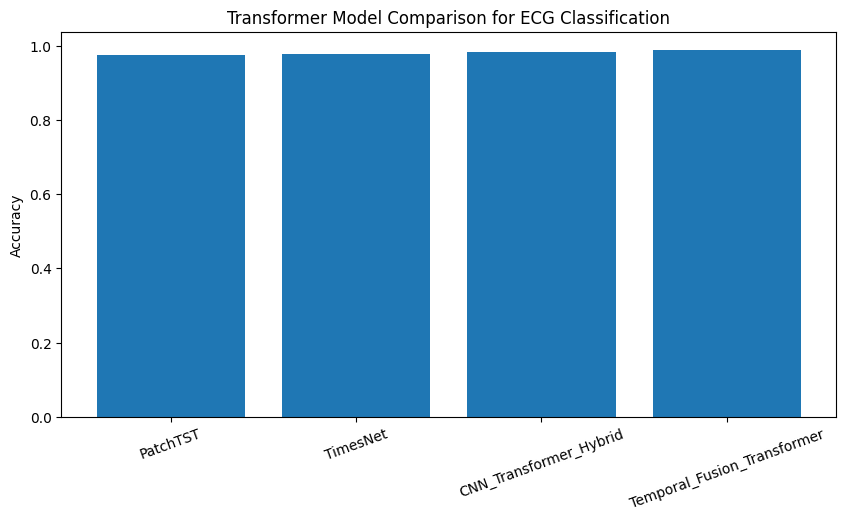

In [44]:

# ════════════════════════════════════════════════════════════════
# ACCURACY COMPARISON PLOT
# ════════════════════════════════════════════════════════════════

transformer_df = pd.DataFrame(results).T

plt.figure(figsize=(10,5))

plt.bar(transformer_df.index, transformer_df["Accuracy"])

plt.xticks(rotation=20)

plt.ylabel("Accuracy")

plt.title("Transformer Model Comparison for ECG Classification")

plt.show()
